In [3]:
import pickle
from tensorflow.keras.models import load_model

# Load trained model
model = load_model('models/lstm_model.h5', compile=False)

# Load processed data payload (new dict format or legacy tuple format)
with open('data/processed_data.pkl', 'rb') as f:
    payload = pickle.load(f)

if isinstance(payload, dict):
    X_test = payload['X_test']
    y_test = payload['y_test']
    target_scaler = payload['target_scaler']
    feature_scaler = payload.get('feature_scaler')
    feature_cols = payload.get('feature_cols', ['Close'])
else:
    # Backward compatibility with older saved tuple
    _, X_test, _, y_test, scaler = payload
    target_scaler = scaler
    feature_scaler = None
    feature_cols = ['Close']

# Generate predictions and bring them back to original price scale
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = target_scaler.inverse_transform(y_pred_scaled).reshape(-1)
y_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

print('✅ All loaded!')
print('X_test shape:', X_test.shape)
print('Feature count:', len(feature_cols))

✅ All loaded!
X_test shape: (274, 60, 11)
Feature count: 11


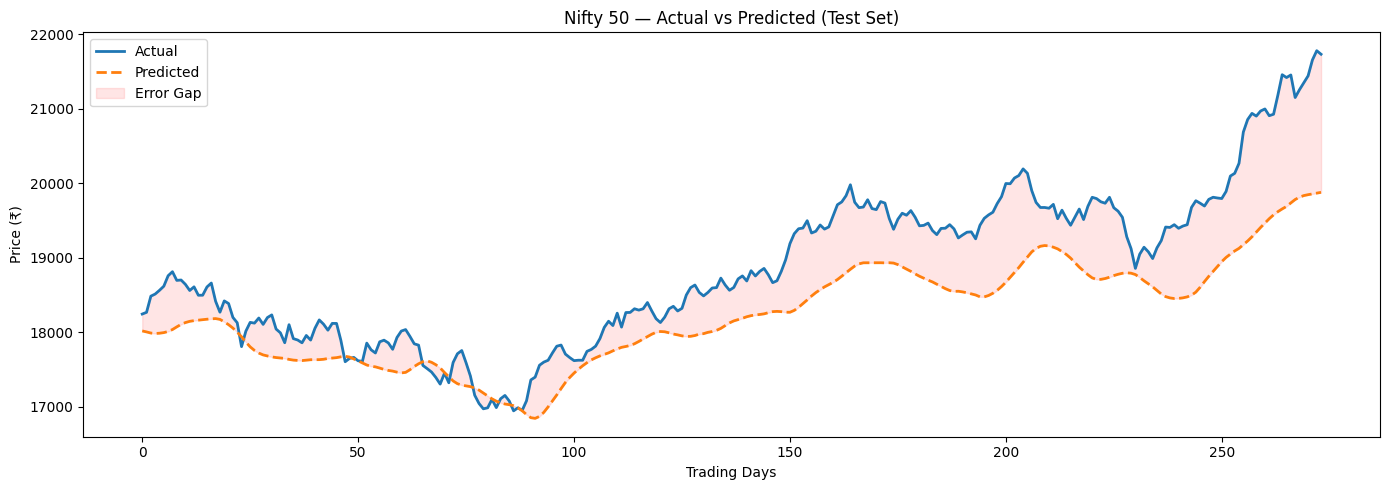

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(y_actual, label='Actual',    color='#1f77b4', linewidth=2)
plt.plot(y_pred,   label='Predicted', color='#ff7f0e', linewidth=2, linestyle='--')
plt.fill_between(range(len(y_actual)),
                 y_actual.flatten(),
                 y_pred.flatten(),
                 alpha=0.1, color='red', label='Error Gap')
plt.title('Nifty 50 — Actual vs Predicted (Test Set)')
plt.xlabel('Trading Days')
plt.ylabel('Price (₹)')
plt.legend()
plt.tight_layout()
plt.show()

# **Forecast Next N Days**

In [5]:
def forecast_future(model, last_sequence, feature_scaler,
                    target_scaler, n_days=30):
    """
    Predict next n_days closing prices using
    the last 60-day window as seed.
    """
    predictions = []
    current_seq = last_sequence.copy()  # shape (60, 11)

    for _ in range(n_days):
        # Predict next scaled value
        input_seq = current_seq.reshape(1, 60, current_seq.shape[1])
        pred_scaled = model.predict(input_seq, verbose=0)[0][0]

        # Inverse transform to get real ₹ price
        pred_price = target_scaler.inverse_transform([[pred_scaled]])[0][0]
        predictions.append(pred_price)

        # Roll the window forward — update Close (index 0) with new prediction
        new_row = current_seq[-1].copy()
        new_row[0] = pred_scaled   # update Close feature
        current_seq = np.vstack([current_seq[1:], new_row])

    return predictions


# Use last 60 days from test set as seed
last_seq = X_test[-1]   # shape (60, 11)

# Forecast 7 days and 30 days
forecast_7  = forecast_future(model, last_seq, feature_scaler,
                               target_scaler, n_days=7)
forecast_30 = forecast_future(model, last_seq, feature_scaler,
                               target_scaler, n_days=30)

print("📅 7-Day Forecast:")
for i, p in enumerate(forecast_7, 1):
    print(f"  Day {i}: ₹{p:,.2f}")

📅 7-Day Forecast:
  Day 1: ₹19,877.62
  Day 2: ₹19,895.70
  Day 3: ₹19,911.30
  Day 4: ₹19,923.96
  Day 5: ₹19,934.11
  Day 6: ₹19,942.19
  Day 7: ₹19,948.64


### **Plot Future Forecast**

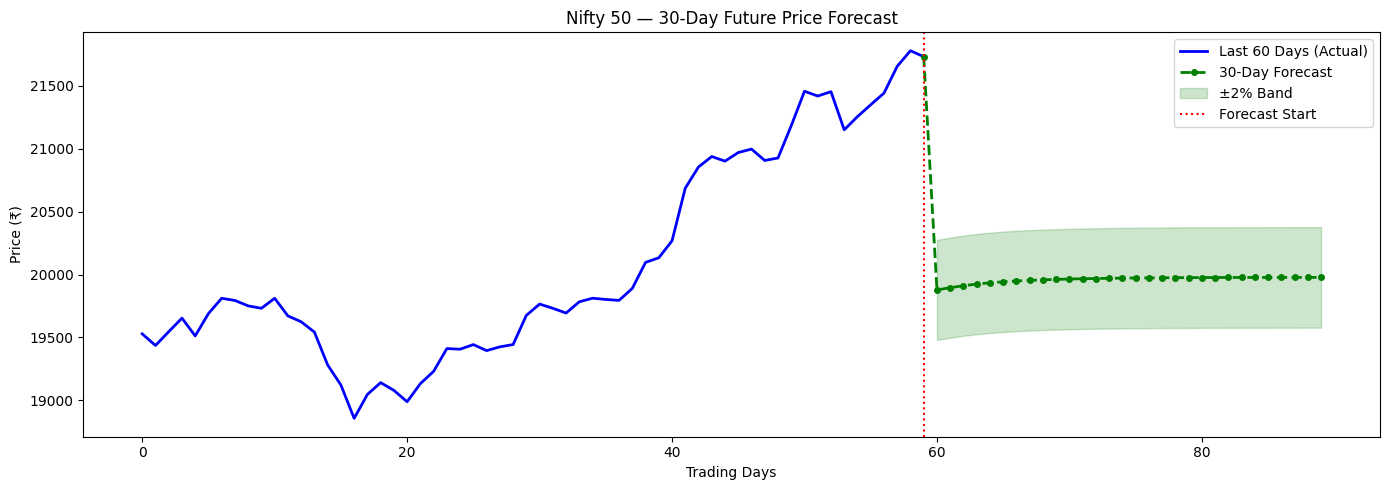

In [6]:
# Show last 60 actual days + 30 day forecast
last_60_actual = y_actual[-60:].flatten()

plt.figure(figsize=(14, 5))

# Historical
plt.plot(range(60), last_60_actual,
         label='Last 60 Days (Actual)', color='blue', linewidth=2)

# Forecast
plt.plot(range(59, 60 + len(forecast_30)),
         [last_60_actual[-1]] + forecast_30,
         label='30-Day Forecast', color='green',
         linewidth=2, linestyle='--', marker='o', markersize=4)

# Confidence band (±2% simple band)
forecast_arr = np.array(forecast_30)
plt.fill_between(range(60, 60 + len(forecast_30)),
                 forecast_arr * 0.98,
                 forecast_arr * 1.02,
                 alpha=0.2, color='green', label='±2% Band')

plt.axvline(x=59, color='red', linestyle=':', label='Forecast Start')
plt.title('Nifty 50 — 30-Day Future Price Forecast')
plt.xlabel('Trading Days')
plt.ylabel('Price (₹)')
plt.legend()
plt.tight_layout()
plt.show()